# Grocery Habit

My grocery habit in 2023. I mainly shop at three places: Aldi, a local Asian market, and Food City. Aldi is for the produce and dairy staples, the local Asian market is for my asian cravings, and Food City is for all other non Asian ingredients. Walmart is for when i need to bulk up on cleaning supplies or non food items.

## Import packages

In [21]:
import pandas as pd
import numpy as np 
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import stats
from datetime import datetime
from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
import re

## Load dataset

In [22]:
# Creating the table in dataframe from a csv file
df_dirty = pd.read_csv(r"C:\Users\Clair\Documents\Code Development\Python Local\personal_finance\Grocery Habit.csv")

In [23]:
df_dirty

,Date,Month,Store,Money Spent
0,6/10/2022,6,Publix,120.58
1,6/26/2022,6,Publix,69.33
2,7/10/2022,7,Publix,84.99
3,7/16/2022,7,Publix,6.43
4,7/23/2022,7,Publix,28.91
...,...,...,...,...
204,3/9/2025,3,Walmart,84.69
205,3/15/2025,3,Food City,51.87
206,3/15/2025,3,Local Asian Market,22.81
207,3/16/2025,3,Walmart,49.93


In [24]:
df_dirty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         209 non-null    object 
 1   Month        209 non-null    int64  
 2   Store        209 non-null    object 
 3   Money Spent  209 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 6.7+ KB


In [25]:
df = df_dirty.copy()

# extract year from Date column using regular expressions  
df["Year"] = df["Date"].apply(lambda x: re.search(r"\d{4}", x).group())  
df_2023 = df[df["Year"] == "2023"]  

<Axes: >

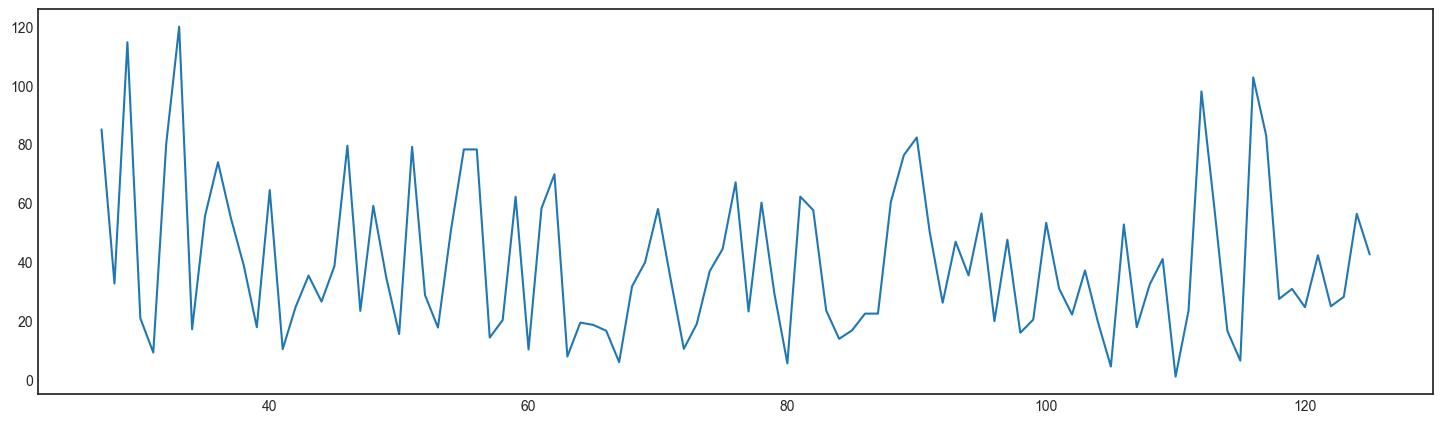

In [26]:
# Big picture - identifying pattern with money spending
df_2023['Money Spent'].plot(figsize = (18,5))

In [27]:
# Checking for null values
df_2023.isnull().values.any()

False

## Clean/modify data

In [28]:
# Converting the date object mm/dd/yyyy to another date object mm-dd-yyyy
df_2023["Date"] = pd.to_datetime(df_2023["Date"]).dt.date
print(df_2023.dtypes,'\n')

# Previewing the table - just checking the Date columns is properly converted
print(df_2023.head(2))

Date            object
Month            int64
Store           object
Money Spent    float64
Year            object
dtype: object 

          Date  Month   Store  Money Spent  Year
27  2023-01-07      1  Publix        84.99  2023
28  2023-01-10      1  Publix        32.57  2023


C:\Users\Clair\AppData\Local\Temp\ipykernel_17576\2167157501.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2023["Date"] = pd.to_datetime(df_2023["Date"]).dt.date


### High level

In [29]:
# Extremes
Cheap = df_2023['Money Spent'].min()
Expensive = df_2023['Money Spent'].max()
Paid = df_2023['Money Spent'].sum().round(2)

print(f'Most cheap trip:\n $',Cheap,'\n')
print(f'Most expensive trip:\n $',Expensive,'\n')
print(f'Amount spent toward feeding myself thus far:\n $',Paid,'\n')

Most cheap trip:
 $ 0.9 

Most expensive trip:
 $ 119.92 

Amount spent toward feeding myself thus far:
 $ 3952.91 



In [30]:
# Basic stats by store
print('The amount of money I spend at each of the main stores:')
Store_group = df_2023.groupby(['Store']).agg({'Money Spent': ['min', 'max', 'mean', 'median']}).round(2)
Store_group.columns = ['min', 'max', 'mean', 'median']
Store_group.reset_index()
Store_group

The amount of money I spend at each of the main stores:


,min,max,mean,median
Store,,,,
Aldi,0.90,37.00,20.98,22.01
Food City,5.83,82.24,44.91,44.48
Local Asian Market,9.11,79.43,40.28,38.26
Publix,16.65,119.92,58.41,47.06
The Fresh Market,14.19,14.19,14.19,14.19
Walmart,4.35,102.62,50.56,56.28


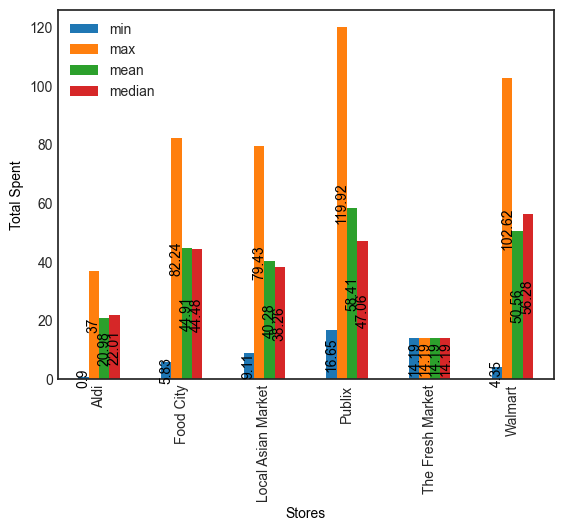

In [31]:
# Stats grouped by store viz
matplotlib.style.use('seaborn-v0_8-white') 
ax = Store_group.plot.bar()
for container in ax.containers:
    ax.bar_label(container, label_type = 'center', rotation = 'vertical', color = 'black', fontsize = 10)

plt.xlabel('Stores', size = 10, color = 'black')
plt.ylabel('Total Spent', size = 10, color = 'black')


plt.show()

In [32]:
# Count of trips by store in the last x months
Trip_count = df_2023['Store'].value_counts()
print(Trip_count)

Store
Aldi                  25
Local Asian Market    24
Food City             22
Walmart               15
Publix                12
The Fresh Market       1
Name: count, dtype: int64


<Axes: ylabel='count'>

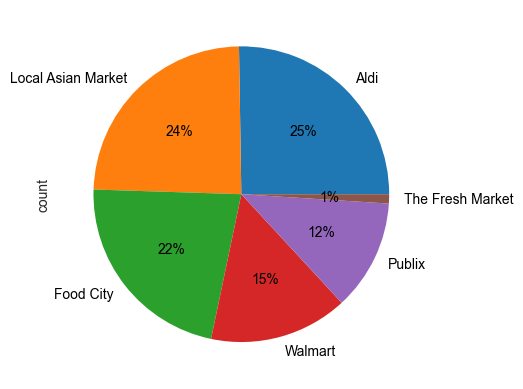

In [33]:
Trip_count.plot(kind = 'pie', y = 'Store', autopct = '%1.0f%%', textprops = {'color':'black'})

### Total

#### Monthly

In [34]:
# Spending per month
Monthly_split_total = df_2023.groupby('Month')['Money Spent'].sum()
Monthly_split_total

Month
1     342.10
2     359.67
3     296.54
4     116.92
5     512.24
6     366.34
7     385.72
8     438.29
9     243.81
10    153.17
11    378.82
12    359.29
Name: Money Spent, dtype: float64

In [35]:
# Spending per month avg
Monthly_split_avg = df_2023.groupby('Month')['Money Spent'].median()
Monthly_split_avg

Month
1     56.320
2     55.175
3     30.835
4     34.700
5     39.610
6     19.280
7     36.700
8     41.055
9     30.810
10    20.730
11    32.230
12    30.730
Name: Money Spent, dtype: float64

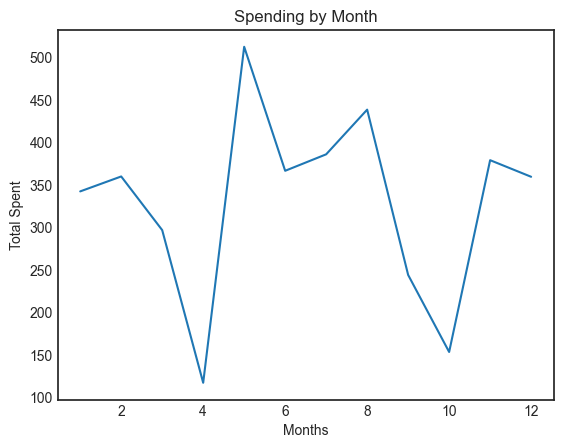

In [36]:
Monthly_split_total.plot(kind = 'line')

plt.title('Spending by Month')
plt.xlabel('Months')
plt.ylabel('Total Spent')

plt.show()

#### Store

In [37]:
# Total Spending by store
Store_split = df_2023.groupby('Store')['Money Spent'].sum()
Store_split

Store
Aldi                  524.62
Food City             988.10
Local Asian Market    966.69
Publix                700.92
The Fresh Market       14.19
Walmart               758.39
Name: Money Spent, dtype: float64

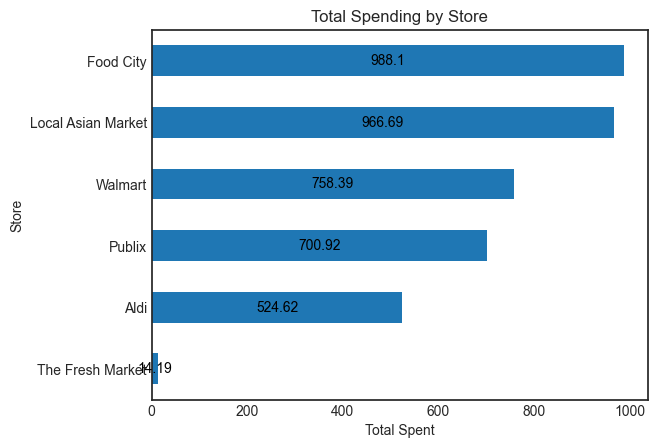

In [38]:
# sort the values in desc order so the barh will be most to least
Store_split = Store_split.sort_values(ascending=True) 
ax = Store_split.plot.barh()
for container in ax.containers:
    ax.bar_label(container, label_type = 'center', color = 'black', fontsize = 10)
    

plt.title('Total Spending by Store')
plt.xlabel('Total Spent')
plt.ylabel('Store')

plt.show()